# Compression Apporaches for Quaternions

In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

from src.data import load_clip, extract_tracks, get_joint_idx

In [43]:
CLIP_IDX = 481

### Summary

- Moderate times uniquness problem, should not effect anything if baking is to be use.

---
## Load Test Clip

In [44]:
original_clip = load_clip(f"data/json/clip_{CLIP_IDX}.json")

original_tracks = original_clip["animationClip"]["tracks"]
number_tracks = extract_tracks(original_tracks, type="number")
quater_tracks = extract_tracks(original_tracks, type="quaternion")

In [45]:
temp = deepcopy(original_clip)
temp["animationClip"]["tracks"] = "tracks"
temp

{'_id': {'$oid': '67cc083cfd081b0548566508'},
 'animationClip': {'name': '-1741424699845',
  'duration': 7.153490000000602,
  'tracks': 'tracks',
  'uuid': '86c11ac9-14a8-4174-a71b-092ee59ed729',
  'blendMode': 2500},
 'recordDate': 1741424699846}

---
## Uniqueness & Times Consistancy

In [46]:
unique_data = []

for track in quater_tracks:
    name = track["name"]
    times = track["times"]
    values = track["values"]

    dup = False
    for data in unique_data:
        if len(times) == len(data["times"]):
            if np.allclose(times, data["times"]) & np.allclose(values, data["values"]):
                data["names"].append(name)
                dup = True
    
    if not dup:
        unique_data.append(dict(
            names=[name],
            times=times, 
            values=values,
        ))

print(f"num tracks: {len(quater_tracks)}")
print(f"num uniques: {len(unique_data)}")

num tracks: 47
num uniques: 47


In [47]:
unique_times_data = []

for track in quater_tracks:
    name = track["name"]
    times = track["times"]
    values = track["values"]

    dup = False
    for data in unique_times_data:
        if len(times) == len(data["times"]):
            if np.allclose(times, data["times"]):
                data["names"].append(name)
                data["values"].append(values)
                dup = True
    
    if not dup:
        unique_times_data.append(dict(
            names=[name],
            times=times, 
            values=[values],
        ))

print(f"num tracks: {len(quater_tracks)}")
print(f"num uniques times: {len(unique_times_data)}")

num tracks: 47
num uniques times: 23


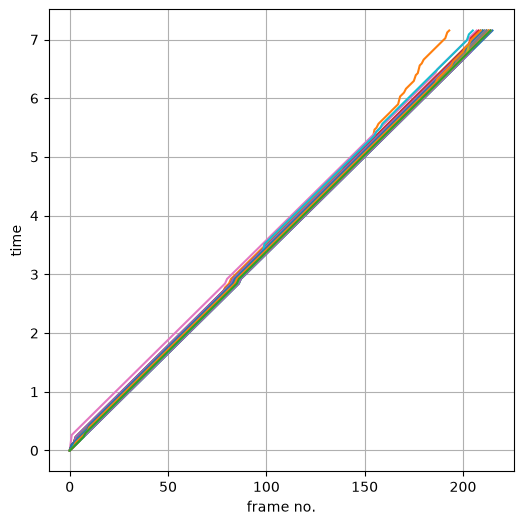

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

for data in unique_times_data:
    ax.plot(np.arange(len(data["times"])), data["times"])

ax.set_xlabel("frame no.")
ax.set_ylabel("time")
ax.grid()
plt.show()